In [1]:
import pandas as pd

data = pd.read_json("data/annotations/instances_train.json", lines=True)


In [2]:
print(data['annotations'][0][0])
print()
print(data['images'][0][0])
print()
print(data['categories'][0][0])

{'id': 14579, 'image_id': 3388, 'bbox': [3619, 1409, 75, 38], 'area': 2850, 'category_id': 2}

{'id': 3388, 'file_name': '3388.jpg', 'height': 2160, 'width': 3840, 'source': {'drone': 'mavic', 'folder_name': 'DJI_0032', 'video': 'DJI_0032.MP4', 'frame_no': 0}, 'date_time': '2020-08-25T14:16:21', 'meta': {'image_name': 'DJI_0032_merged.MP4_image0.png', 'datetime(utc)': '2020-08-25 12:16:22', 'latitude': 47.673596, 'longitude': 9.270249, 'height_above_takeoff(meter)': 9.699526973483694, 'speed(m/s)': 0.0, 'xspeed(m/s)': 0.0, 'yspeed(m/s)': 0.0, 'zspeed(m/s)': 0.0, 'compass_heading(degrees)': 175.8, 'gimbal_heading(degrees)': 154.4, 'gimbal_pitch(degrees)': -2.5}}

{'supercategory': 'ignored', 'id': 0, 'name': 'ignored'}


In [3]:
import os
import pandas as pd

# Convert dataset from COCO to YOLO
train_json = "data/annotations/instances_train.json"
val_json = "data/annotations/instances_val.json"

train_data = pd.read_json(train_json, lines=True)
val_data = pd.read_json(val_json, lines=True)

In [4]:
train_data['annotations'][0][0]

{'id': 14579,
 'image_id': 3388,
 'bbox': [3619, 1409, 75, 38],
 'area': 2850,
 'category_id': 2}

In [5]:
val_data['annotations'][0][0]

{'id': 14808,
 'image_id': 3464,
 'bbox': [1698, 1619, 230, 164],
 'area': 37720,
 'category_id': 1}

In [8]:
def format_data(data, output_dir):
    # lookup for image id
    img_lookup = {img['id']: img for img in data['images'][0]}

    os.makedirs(output_dir, exist_ok=True)

    for i, ann in enumerate(data['annotations'][0]):
        if data['annotations'][0][i]['category_id'] == 1:
            img_id = ann['image_id']
            img_info = img_lookup[img_id]
            
            img_w = img_info['width']
            img_h = img_info['height']
            
            # COCO bbox: [x_min, y_min, width, height]
            bbox = ann['bbox']
            
            # Normalized to [0, 1]
            x_center = (bbox[0] + bbox[2] / 2) / img_w
            y_center = (bbox[1] + bbox[3] / 2) / img_h
            w = bbox[2] / img_w
            h = bbox[3] / img_h
            
            class_id = 1

            # Write to file
            file_name = os.path.splitext(img_info['file_name'])[0] + ".txt"
            file_path = os.path.join(output_dir, file_name)
            
            with open(file_path, 'a') as f:
                f.write(f'{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n')

        else: pass

format_data(val_data, "data/val/labels")
format_data(train_data, "data/train/labels")

In [ ]:
import matplotlib.pyplot as plt

image = "data/val/images/10800.jpg"
img = plt.imread(image)
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

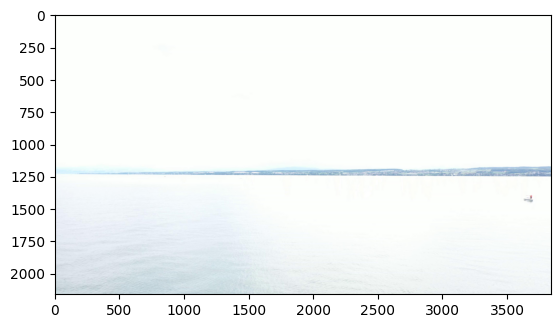

In [27]:
import matplotlib.pyplot as plt

image = "data/train/images/3388.jpg"
img = plt.imread(image)
plt.imshow(img)
plt.show()

In [ ]:
import matplotlib.patches as patches

# bbox format assumed: [x_min, y_min, width, height], normalized to [0,1]
bbox = [
    [0.424219, 0.490278, 0.015104, 0.016667],
    [0.423568, 0.447454, 0.007552, 0.017130],
    [0.394531, 0.400000, 0.010417, 0.012037]
]

h, w = img.shape[:2]

fig, ax = plt.subplots(1, figsize=(12, 12))
ax.imshow(img)

for b in bbox:
    x, y, bw, bh = b
    rect = patches.Rectangle(
        (x * w, y * h),
        bw * w,
        bh * h,
        linewidth=2,
        edgecolor='r',
        facecolor='none'
    )
    ax.add_patch(rect)
    
plt.axis('off')
plt.show()

In [17]:
import torch

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Force PyTorch to use GPU
torch.cuda.set_device(0)
device = torch.device('cuda:0')

GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB


In [18]:
from ultralytics import YOLO

# Load YOLOv8n-p2 model (P2 head for better small object detection)
# P2 adds an extra detection head at 1/4 resolution for detecting smaller objects
model = YOLO('yolov8n-p2-BiFPN.yaml')
model.info()

YOLOv8n-p2-BiFPN summary: 161 layers, 5,109,804 parameters, 5,109,788 gradients, 21.3 GFLOPs


(161, 5109804, 5109788, 21.3274112)

In [ ]:
# Train the model on GPU with P2 head
results = model.train(
    data=r'D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device='cuda:0',
    workers=8,
    patience=20,
    save=True,
    project='runs/detect',
    name='seadronessee_yolov8n_p2_BiFPN',
    exist_ok=True,
    pretrained=True,
    optimizer='auto',  # Auto = SGD
    verbose=True,
    seed=42,
    val=True,
    plots=True,
    cache=False  # Set this to true if you have a lot of RAM, 9GB of free RAM required
)

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.11.9 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bbox_loss=ciou, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yol

KeyboardInterrupt: 

In [ ]:
# Evaluate the model on validation set
metrics = model.val()

print(f"\nmAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

In [ ]:
from ultralytics import YOLO

model_new = YOLO(r'D:\Python\Projects\Community\School\DAT\SeaDroneSee\best.pt')

In [ ]:
# Run inference on test images
import glob
from ultralytics import YOLO

model_new = YOLO('best.pt')
test_images = glob.glob(r'D:\Python\Projects\Community\School\DAT\SeaDroneSee\test_images\*')

if test_images:
    results = model_new.predict(
        source=test_images[:5],  # Predict on first 5 test images
        save=True,
        conf=0.25,
        device=0
    )
    
    # Display predictions
    for r in results:
        fig, ax = plt.subplots(1, figsize=(12, 8))
        ax.imshow(r.plot())
        ax.axis('off')
        plt.show()

In [8]:
import torch
from ultralytics import YOLO

model = YOLO(r"D:\Python\Projects\Community\School\DAT\SeaDroneSee\best.pt")
device = "cuda:0" if torch.cuda.is_available() else "cpu"

metrics = model.val(
    data=r"D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\data_fixed.yaml",
    split="val",
    imgsz=640,
    batch=16,
    device=device,
    plots=True,
    project=r"D:\Python\Projects\Community\School\DAT\SeaDroneSee\analysis_outputs",
    name="val_fixed_best_pt",
    exist_ok=True,
    verbose=True,
)

result_payload = {
    "device": device,
    "map50": float(metrics.box.map50),
    "map50_95": float(metrics.box.map),
    "precision": float(metrics.box.p.mean()) if hasattr(metrics.box.p, 'mean') else float(metrics.box.p),
    "recall": float(metrics.box.r.mean()) if hasattr(metrics.box.r, 'mean') else float(metrics.box.r),
    "val_run_dir": str(metrics.save_dir),
}

out_json = Path(r"D:\Python\Projects\Community\School\DAT\SeaDroneSee\analysis_outputs\map_metrics_val_fixed_best_pt.json")
out_json.write_text(json.dumps(result_payload, indent=2), encoding="utf-8")

print(f"\nDevice used: {device}")
print(f"mAP50: {result_payload['map50']:.4f}")
print(f"mAP50-95: {result_payload['map50_95']:.4f}")
print(f"Precision: {result_payload['precision']:.4f}")
print(f"Recall: {result_payload['recall']:.4f}")
print(f"Saved metrics: {out_json}")

Ultralytics 8.4.21  Python-3.11.9 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv8n-p2 summary (fused): 91 layers, 2,921,304 parameters, 0 gradients, 12.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 79.916.6 MB/s, size: 655.1 KB)
val: Scanning D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\val_fixed\labels... 8930 images, 2032 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8930/8930 598.4it/s 14.9s<0.0s
val: D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\val_fixed\images\13831.jpg: 1 duplicate labels removed
val: D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\val_fixed\images\13832.jpg: 1 duplicate labels removed
val: D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\val_fixed\images\9560.jpg: 1 duplicate labels removed
val: D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\val_fixed\images\9561.jpg: 1 duplicate labels removed
val: D:\Python\Projects\Community\School\DAT\SeaDroneSee\data\val_fixed\images\95